# EDA — Predicting Daily Citi Bike Ridership

**Notebook 1 of 3.** In this notebook I explore the dataset I built in Part 1 and look for
data quality problems. I don't fix anything here — the fixes happen in `preprocessing.ipynb`.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('../data/citibike_weather_daily.csv')

## E1: Load and Inspect

First I check the shape, the first few rows, and the dtypes. The data dictionary says
`ride_date` should be a date, `num_rides` and `month` should be integers, and the weather
columns should be floats.

In [2]:
print(df.shape)
df.head()

(1610, 10)


,ride_date,num_rides,avg_duration_min,temp_f,max_temp_f,min_temp_f,wind_speed_knots,precip_in,day_of_week,month
0,2013-07-01,16650,16.309988,74.8,78.1,73.4,7.8,0.00,Monday,7
1,2013-07-02,22745,15.968826,76.1,82.9,73.0,8.0,0.73,Tuesday,7
2,2013-07-03,21864,16.238808,78.5,84.9,73.9,8.8,0.06,Wednesday,7
3,2013-07-04,22326,21.218474,82.0,91.0,73.9,8.6,0.96,Thursday,7
4,2013-07-05,21842,18.040443,84.4,93.0,75.9,9.0,0.00,Friday,7


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1610 entries, 0 to 1609
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ride_date         1610 non-null   str    
 1   num_rides         1610 non-null   int64  
 2   avg_duration_min  1610 non-null   float64
 3   temp_f            1610 non-null   float64
 4   max_temp_f        1610 non-null   float64
 5   min_temp_f        1610 non-null   float64
 6   wind_speed_knots  1610 non-null   float64
 7   precip_in         1610 non-null   float64
 8   day_of_week       1610 non-null   str    
 9   month             1610 non-null   int64  
dtypes: float64(6), int64(2), str(2)
memory usage: 125.9 KB


### What I found in E1

Almost every column loaded with the right type, except one:

- **`ride_date` loaded as `object` (a string), not as a date.**

My hypothesis for why: a CSV file is just text, so pandas has no way to know that
"2013-07-01" is a date. It only auto-converts columns that look like numbers. Until this is
fixed I can't do date math (like finding missing days or extracting the year).

I'm not fixing it here — that happens in preprocessing (C1).

## E2: Profile the Distributions

Now I run `.describe()` and plot a histogram of each numeric column. For each one I ask:
are the min and max physically possible?

The NOAA weather documentation says missing values are coded as numbers instead of being
left blank: **9999.9** for temperatures, **999.9** for wind, and **99.99** for precipitation.
I need to check if any of those codes are hiding in my data.

In [4]:
df.describe()

,num_rides,avg_duration_min,temp_f,max_temp_f,min_temp_f,wind_speed_knots,precip_in,month
count,1610.000000,1610.000000,1610.000000,1610.000000,1610.000000,1610.000000,1610.000000,1610.000000
mean,32986.783230,15.425627,57.368509,67.317081,49.295901,9.013913,0.178398,6.544099
std,16910.147968,3.652633,17.876211,18.349408,17.832318,3.241211,2.508762,3.323772
min,876.000000,9.495396,8.300000,18.000000,1.000000,2.300000,0.000000,1.000000
25%,20505.500000,13.112342,43.625000,53.700000,35.700000,6.700000,0.000000,4.000000
50%,32272.500000,14.860057,59.300000,70.000000,51.100000,8.500000,0.000000,7.000000
75%,42915.750000,17.121551,73.500000,82.900000,64.900000,10.800000,0.060000,9.000000
max,78458.000000,81.110084,92.500000,100.900000,82.900000,22.400000,99.990000,12.000000


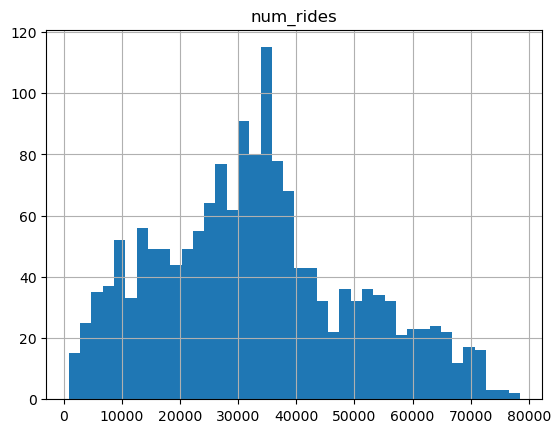

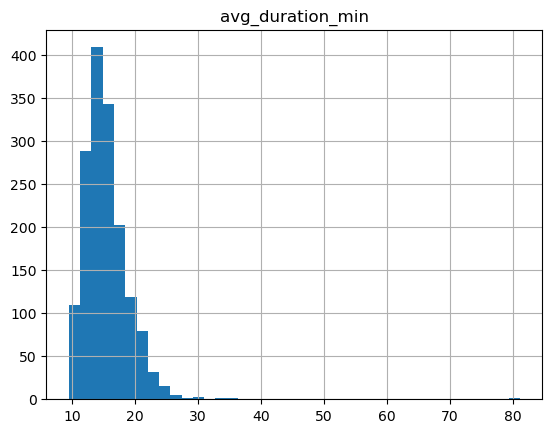

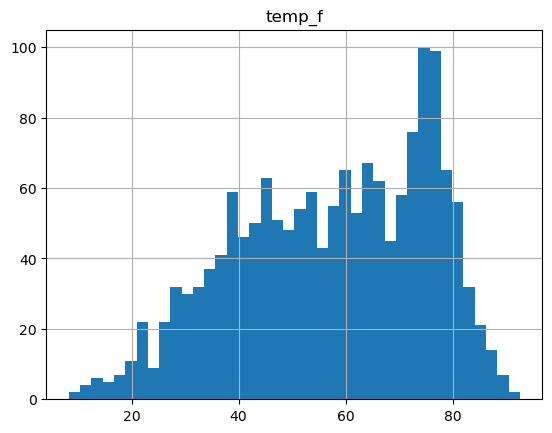

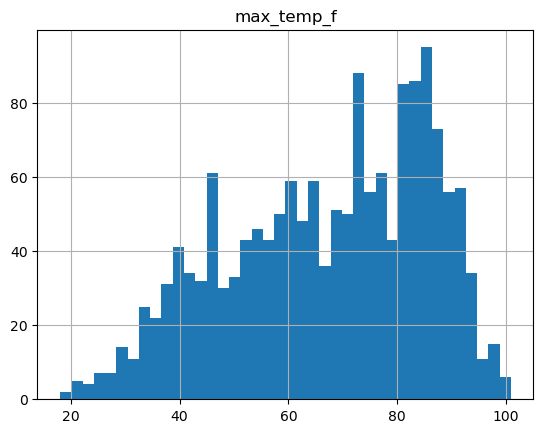

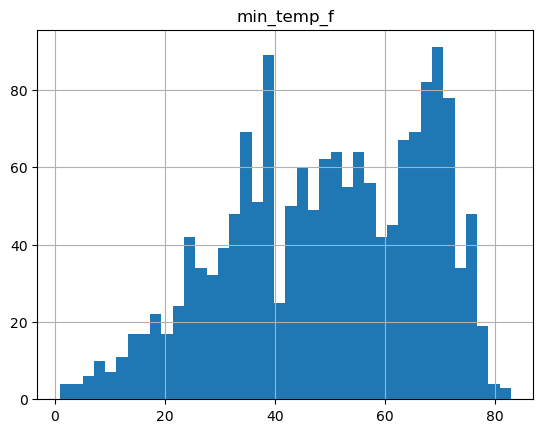

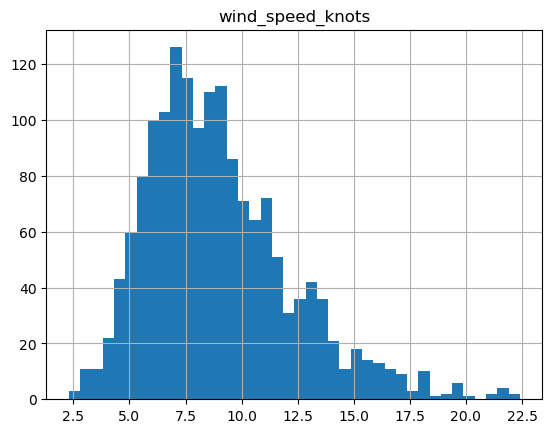

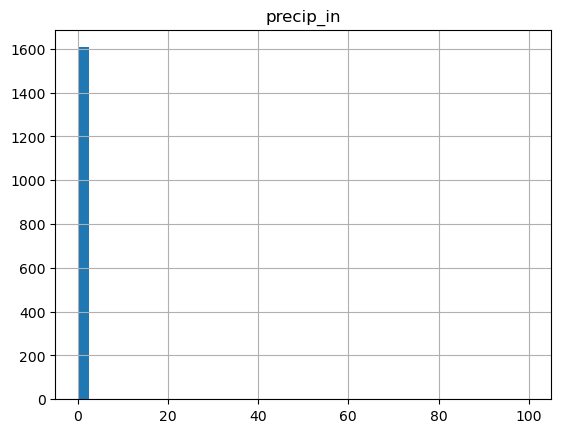

In [5]:
numeric_cols = ['num_rides', 'avg_duration_min', 'temp_f', 'max_temp_f',
                'min_temp_f', 'wind_speed_knots', 'precip_in']

for col in numeric_cols:
    df[col].hist(bins=40)
    plt.title(col)
    plt.show()

In [6]:
# Check for the NOAA missing-value codes
print('temp_f = 9999.9:          ', (df['temp_f'] == 9999.9).sum())
print('max_temp_f = 9999.9:      ', (df['max_temp_f'] == 9999.9).sum())
print('min_temp_f = 9999.9:      ', (df['min_temp_f'] == 9999.9).sum())
print('wind_speed_knots = 999.9: ', (df['wind_speed_knots'] == 999.9).sum())
print('precip_in = 99.99:        ', (df['precip_in'] == 99.99).sum())

temp_f = 9999.9:           0
max_temp_f = 9999.9:       0
min_temp_f = 9999.9:       0
wind_speed_knots = 999.9:  0
precip_in = 99.99:         1


In [7]:
# Found one! Look at the row with precip_in = 99.99
df[df['precip_in'] == 99.99]

,ride_date,num_rides,avg_duration_min,temp_f,max_temp_f,min_temp_f,wind_speed_knots,precip_in,day_of_week,month
951,2016-02-11,18748,13.523118,28.1,39.9,23.0,17.3,99.99,Thursday,2


In [8]:
# Look at the days around it to see what the weather was really like that week
df.loc[948:954, ['ride_date', 'temp_f', 'precip_in']]

,ride_date,temp_f,precip_in
948,2016-02-08,36.7,0.00
949,2016-02-09,30.2,0.06
950,2016-02-10,35.4,0.01
951,2016-02-11,28.1,99.99
952,2016-02-12,21.7,0.05
953,2016-02-13,21.6,0.00
954,2016-02-14,8.3,0.00


### What I found in E2

- **`precip_in` has a max of 99.99 inches.** That is not rain — the rainiest day in NYC
  history was about 9 inches. It's the NOAA missing-value code. Exactly **one row** has it:
  **2016-02-11**. The days around it were basically dry (0.00 to 0.06 inches), so the real
  value was probably close to zero. This also explains why `.describe()` shows a mean of
  0.18 for precipitation with a huge std — one fake value of 99.99 pulls it up.
- No temperature or wind sentinel codes made it into my data.
- Everything else looks physically possible: temps from 8.3°F to 100.9°F is a real NYC range,
  and `num_rides` from 876 to 78,458 is a big range but believable (the low days turn out to
  be around snowstorms).
- `avg_duration_min` has some big outliers (max ~81 min vs a median of ~15), but this column
  can't be used in the model anyway because of Rule 1 — it's calculated from that day's rides.

The fix for the 99.99 value happens in preprocessing (C2).

## E3: Relationships With the Target

Scatter plots of `num_rides` against each weather variable, to see which relationships the
model can use.

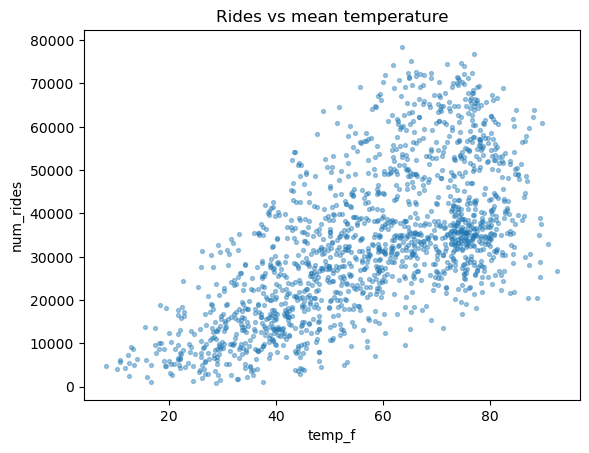

In [9]:
plt.scatter(df['temp_f'], df['num_rides'], s=8, alpha=0.4)
plt.xlabel('temp_f')
plt.ylabel('num_rides')
plt.title('Rides vs mean temperature')
plt.show()

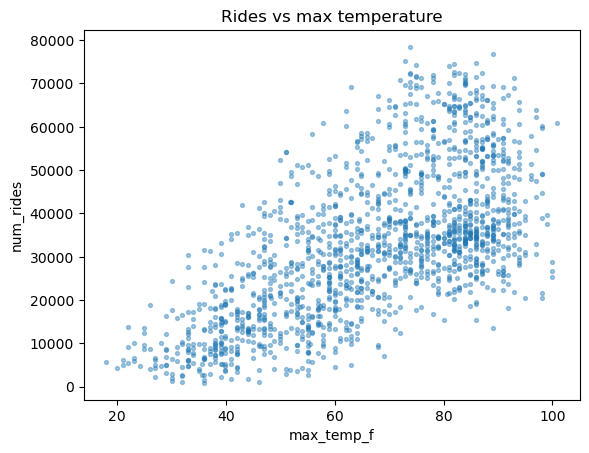

In [10]:
plt.scatter(df['max_temp_f'], df['num_rides'], s=8, alpha=0.4)
plt.xlabel('max_temp_f')
plt.ylabel('num_rides')
plt.title('Rides vs max temperature')
plt.show()

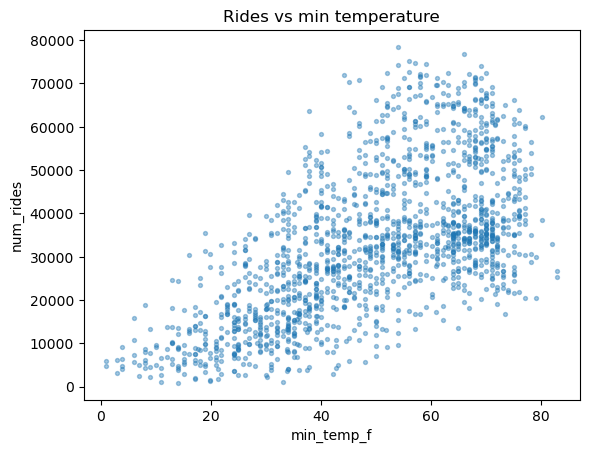

In [11]:
plt.scatter(df['min_temp_f'], df['num_rides'], s=8, alpha=0.4)
plt.xlabel('min_temp_f')
plt.ylabel('num_rides')
plt.title('Rides vs min temperature')
plt.show()

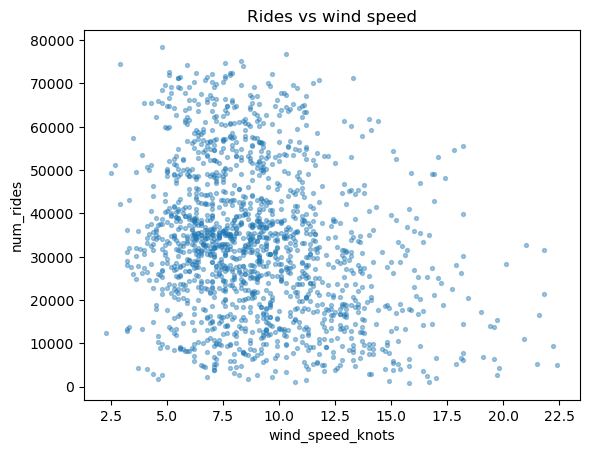

In [12]:
plt.scatter(df['wind_speed_knots'], df['num_rides'], s=8, alpha=0.4)
plt.xlabel('wind_speed_knots')
plt.ylabel('num_rides')
plt.title('Rides vs wind speed')
plt.show()

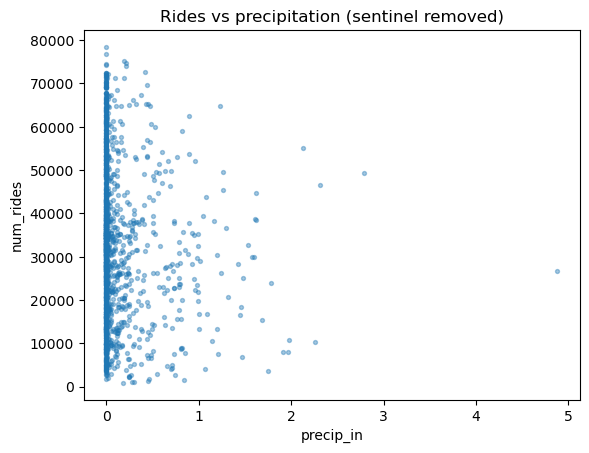

In [13]:
# For precipitation I leave out the 99.99 sentinel, otherwise the x-axis is unreadable
no_sentinel = df[df['precip_in'] < 99]
plt.scatter(no_sentinel['precip_in'], no_sentinel['num_rides'], s=8, alpha=0.4)
plt.xlabel('precip_in')
plt.ylabel('num_rides')
plt.title('Rides vs precipitation (sentinel removed)')
plt.show()

In [14]:
# Does ridership keep climbing forever as it gets hotter? Compare warm days vs the hottest days.
warm_days = df[(df['temp_f'] > 70) & (df['temp_f'] <= 85)]
hot_days = df[df['temp_f'] > 85]

print('Average rides on 70-85 degree days:', round(warm_days['num_rides'].mean()))
print('Average rides on 85+ degree days:  ', round(hot_days['num_rides'].mean()))

Average rides on 70-85 degree days: 43122
Average rides on 85+ degree days:   42379


### What I found in E3

- **Temperature is the strongest relationship** — clearly positive. All three temperature
  columns show basically the same picture, which makes sense because they move together
  (this is what Rule 2 warns about).
- **The temperature relationship is a curve, not a straight line.** Rides climb as it warms
  up, but on the hottest days (above 85°F) ridership actually stops climbing — the average
  on 85+ degree days is slightly *lower* than on 70–85 degree days. People don't ride more
  in a heat wave. I need to remember this for feature engineering, because a straight line
  can't bend.
- **Precipitation is negative but weak-looking**: most days have zero rain, and the rainy
  days sit lower.
- **Wind is weakly negative** — a lot of spread, slight downward lean.

## E4: Ridership Over Time

Plot the whole date range, then compare the same month across different years.

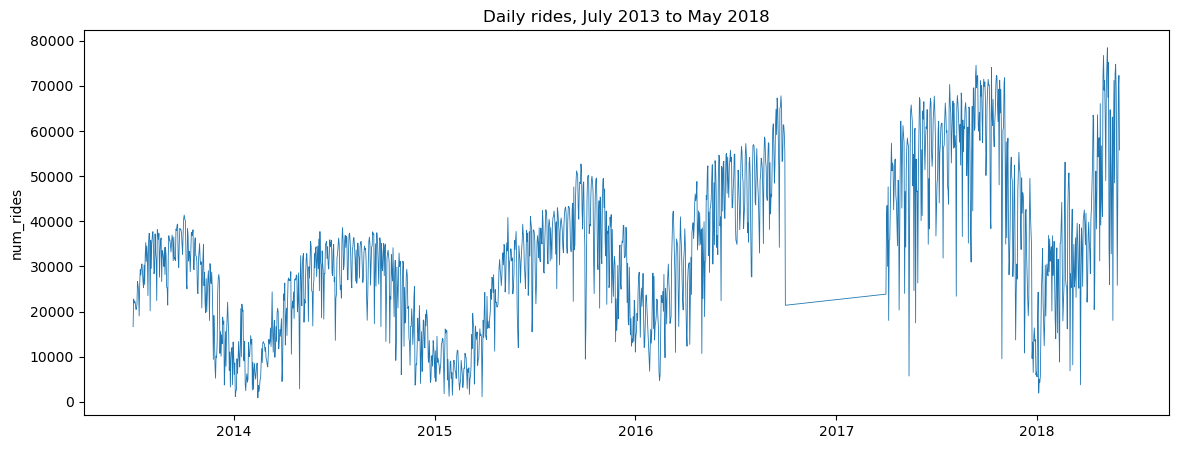

In [15]:
# ride_date is still a string (the E1 problem), so I convert a copy just for plotting.
# The permanent fix belongs in preprocessing.
df['date_temp'] = pd.to_datetime(df['ride_date'])
df['year_temp'] = df['date_temp'].dt.year

plt.figure(figsize=(14, 5))
plt.plot(df['date_temp'], df['num_rides'], linewidth=0.6)
plt.ylabel('num_rides')
plt.title('Daily rides, July 2013 to May 2018')
plt.show()

year_temp
2013    27207.0
2014    31253.0
2015    35022.0
2016    44520.0
2017    55987.0
Name: num_rides, dtype: float64


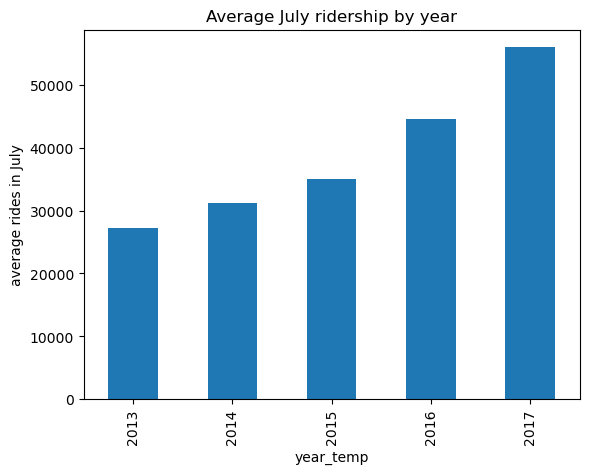

In [16]:
# Average July ridership, year by year
july = df[df['month'] == 7]
july_by_year = july.groupby('year_temp')['num_rides'].mean().round()
print(july_by_year)

july_by_year.plot(kind='bar')
plt.ylabel('average rides in July')
plt.title('Average July ridership by year')
plt.show()

### What I found in E4

A July day in 2017 is **not** the same as a July day in 2013, even with identical weather.
Average July ridership went from about **27,000 rides/day in 2013 to about 56,000 in 2017** —
it doubled. The reason is that the Citi Bike system itself grew: more stations, more bikes,
more members every year.

**What this means for my model:** a model that only knows the weather and the day of week
has no idea what year it is. It would predict the same number for July 2013 and July 2017,
over-predicting the early years and under-predicting the later ones. The model needs a
**trend feature** so it knows how old the system is — I build that in preprocessing (C4).

I can also see a gap in the line around late 2016 — E6 investigates that.

## E5: The Weekly Rhythm

Compare average ridership across the days of the week.

day_of_week
Monday       33297.0
Tuesday      35485.0
Wednesday    36265.0
Thursday     35738.0
Friday       34229.0
Saturday     28563.0
Sunday       27261.0
Name: num_rides, dtype: float64


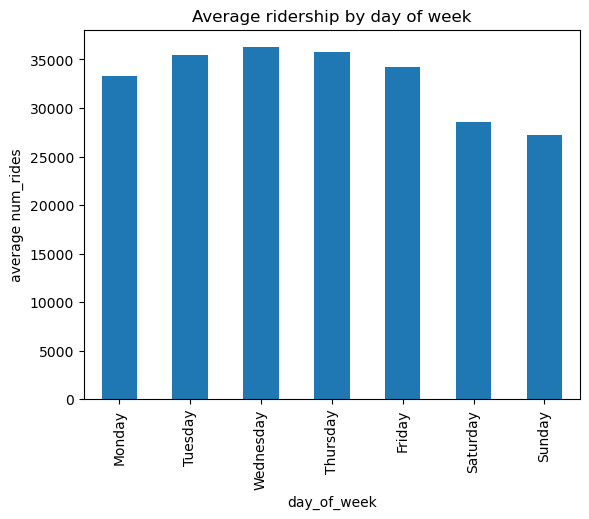

In [17]:
dow_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

avg_by_day = df.groupby('day_of_week')['num_rides'].mean()
avg_by_day = avg_by_day.reindex(dow_order)
print(avg_by_day.round())

avg_by_day.plot(kind='bar')
plt.ylabel('average num_rides')
plt.title('Average ridership by day of week')
plt.show()

### What I found in E5

**Weekdays are busier than weekends.** Wednesday and Thursday are the busiest (~36,000 rides),
Saturday and Sunday are the quietest (~27,000–28,500) — about a 20–25% drop on weekends.

That matches my intuition: Citi Bike is heavily a **commuter system**. Monday to Friday people
ride to work; weekends are lighter leisure riding. So day of week clearly matters for the
model — but the model can't multiply the word "Tuesday" by a number, so preprocessing (C3)
will one-hot encode it.

## E6: The Missing Days

My table has 1,610 rows, but the date range covers more days than that. How many dates are
missing, and where do the gaps fall?

In [18]:
all_days = pd.date_range(df['date_temp'].min(), df['date_temp'].max())
print('Days in the full span:', len(all_days))
print('Rows I actually have: ', len(df))

missing = all_days[~all_days.isin(df['date_temp'])]
print('Missing dates:        ', len(missing))

Days in the full span: 1796
Rows I actually have:  1610
Missing dates:         186


In [19]:
# Where are they? Count the missing dates by year and month.
missing_series = pd.Series(missing)
missing_by_month = missing_series.dt.strftime('%Y-%m').value_counts().sort_index()
print(missing_by_month)

2016-01     4
2016-10    31
2016-11    30
2016-12    31
2017-01    31
2017-02    28
2017-03    31
Name: count, dtype: int64


In [20]:
# The 2016-01 gap is only 4 days — which ones exactly?
jan_gap = missing_series[missing_series < '2016-06-01']
print(jan_gap)

0   2016-01-23
1   2016-01-24
2   2016-01-25
3   2016-01-26
dtype: datetime64[us]


### What I found in E6

**186 dates are missing**, in two very different gaps:

1. **Jan 23–26, 2016 (4 days).** That is exactly the weekend of the January 2016 blizzard
   (Winter Storm Jonas, ~27 inches of snow). NYC banned road travel and Citi Bike shut down,
   so there were **no trip rows at all** those days. This gap came from the **rides side**
   of my Part 1 join.
2. **Oct 2016 through Mar 2017 (182 days — six full months).** Every single day is missing.
   No weather event lasts six months, so this looks like the **weather station's data is
   simply absent** from the NOAA table for that stretch. This gap came from the **weather
   side** of the join.

Because Part 1 used an **INNER JOIN**, any day missing from either table disappears from the
CSV completely — no error, no blank row, just silently gone. That's why the file has 186
fewer rows than the calendar.

## EDA Summary — problems to fix in preprocessing

1. `ride_date` is a string → convert to datetime (C1)
2. `precip_in` = 99.99 sentinel on 2016-02-11 → replace and impute (C2)
3. `day_of_week` is text → one-hot encode (C3)
4. The system grew every year → build a trend feature (C4)
5. Temperature effect flattens on the hottest days → a squared temp feature could help (C5)
6. 186 missing days → documented; those rows can't be recovered
7. The three temperature columns move together → only use one in the model (Rule 2)
8. `avg_duration_min` comes from the same day's rides → not allowed as a feature (Rule 1)